# Part 4: Putting it all together
**Author**: Serena Day   
**Created on:** Sep 24, 2026

**Table of Contents**

1. [Planning Graph 1](#sec1)
2. [Making Graph 1](#sec2)
3. [Planning Graph 2](#sec3)
4. [Making Graph 2](#sec4)

<h2 id="sec1"> Planning Graph 1 </h2>


Information I need:
1. List of Dramas
2. Their cumulative wikipedia pageviews from 2022-06-01 to 2024-06-01

How I will obtain this data:
1. Pictured on the graph
2. 
    *  Use mwviews to access the pages
    * p.article_views('en.wikipedia', ['Page Title’], start='startdate', end='enddate')
    * Export into a pandas df (rows= kdrama, column=views)

<h2 id="sec2"> Making Graph 1 </h2>


#### Creating list of dramas

In [61]:
dramas = ['The Glory (TV series)', "Moving (South Korean TV series)", "My Demon", "King the Land", "Gyeongseong Creature", "Twinkling Watermelon",
          "Death's Game", "Crash Course in Romance", "Welcome to Samdal-ri", "Celebrity (South Korean TV series)", "A Time Called You", 
          "Perfect Marriage Revenge", "See You in My 19th Life", "The Good Bad Mother", "My Lovely Liar", "Doona!", "Love to Hate You (TV series)",
          "Daily Dose of Sunshine", "Destined with You"]

#### Obtaining page view for each drama

In [107]:
# Creating helper function to get page view for each page
def getViews(dramaName):
    views = p.article_views('en.wikipedia', dramaName,  start='20220601', end='20240601')
    df = pd.DataFrame(views)
    df[df.isna()]=0
    df["Total Views"] = df.sum(axis=1)
    return df["Total Views"].values[0]


In [111]:
import pandas as pd
views = []
for drama in dramas:
    views.append(getViews(drama))

data = {"Kdrama": dramas, "Views": views}
viewsByDrama = pd.DataFrame(data, columns = ["Kdrama","Views"])

#### Creating the graphic

Text(0.5, 0, 'Total Pageviews')

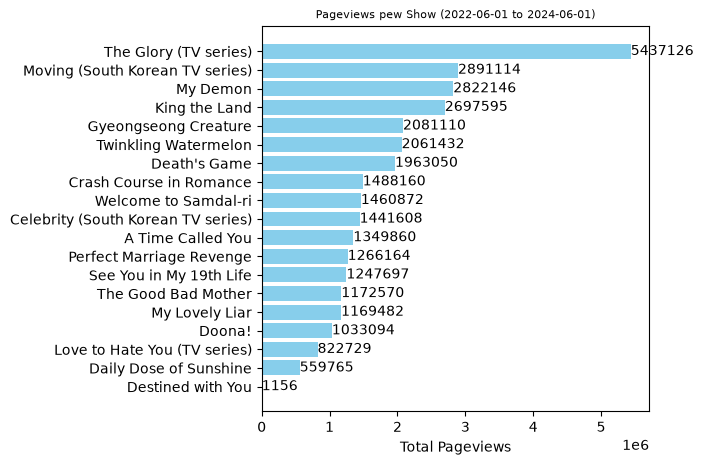

In [136]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5))
bars = ax.barh(viewsByDrama["Kdrama"], viewsByDrama["Views"], color="skyblue")
ax.set_title('Pageviews pew Show (2022-06-01 to 2024-06-01)', fontsize = 8)
ax.invert_yaxis()
ax.bar_label(bars, fmt='%d')
ax.set_xlabel('Total Pageviews')


<h2 id="sec3"> Planning Graph 2 </h2>


Information I need:
* Daily views across a period of time for each kdrama

Plan:
* Make a pandas df with columns as the kdramas and rows as views from each day within the collected period


<h2 id="sec4"> Making Graph 2 </h2>


In [162]:
# Gathering the views for each drama for each date
from mwviews.api import PageviewsClient
p = PageviewsClient(user_agent="sd120")

matrix = []

views = p.article_views('en.wikipedia', dramas[0],  start='20220601', end='20240601')
df = pd.DataFrame(views).fillna(0)

for drama in dramas[1:]:
    views = p.article_views('en.wikipedia', drama, start='20220601', end='20240601')
    newRow = pd.DataFrame(views).fillna(0)
    df = pd.concat([df,newRow])

df = df.T

In [166]:
df.head()

,The_Glory_(TV_series),Moving_(South_Korean_TV_series),My_Demon,King_the_Land,Gyeongseong_Creature,Twinkling_Watermelon,Death's_Game,Crash_Course_in_Romance,Welcome_to_Samdal-ri,Celebrity_(South_Korean_TV_series),A_Time_Called_You,Perfect_Marriage_Revenge,See_You_in_My_19th_Life,The_Good_Bad_Mother,My_Lovely_Liar,Doona!,Love_to_Hate_You_(TV_series),Daily_Dose_of_Sunshine,Destined_with_You
2022-06-01,0,199,0,0,0,0,0,0,0,0,134,0,0,0,0,0,0,0,0
2022-06-02,0,176,0,0,0,0,0,0,0,0,128,0,0,0,0,0,0,0,0
2022-06-03,0,183,0,0,0,0,0,0,0,0,127,0,0,0,0,0,0,0,0
2022-06-04,0,167,0,0,0,0,0,0,0,0,154,0,0,0,0,0,0,0,0
2022-06-05,0,212,0,0,0,0,0,0,0,0,137,0,0,0,0,0,0,0,0


In [181]:
df.iloc[:,0].dtype

dtype('O')

In [228]:
midpoint = df.iloc[:,1].idxmax()
midpoint - pd.Timedelta(days=100)

Timestamp('2023-05-09 00:00:00')

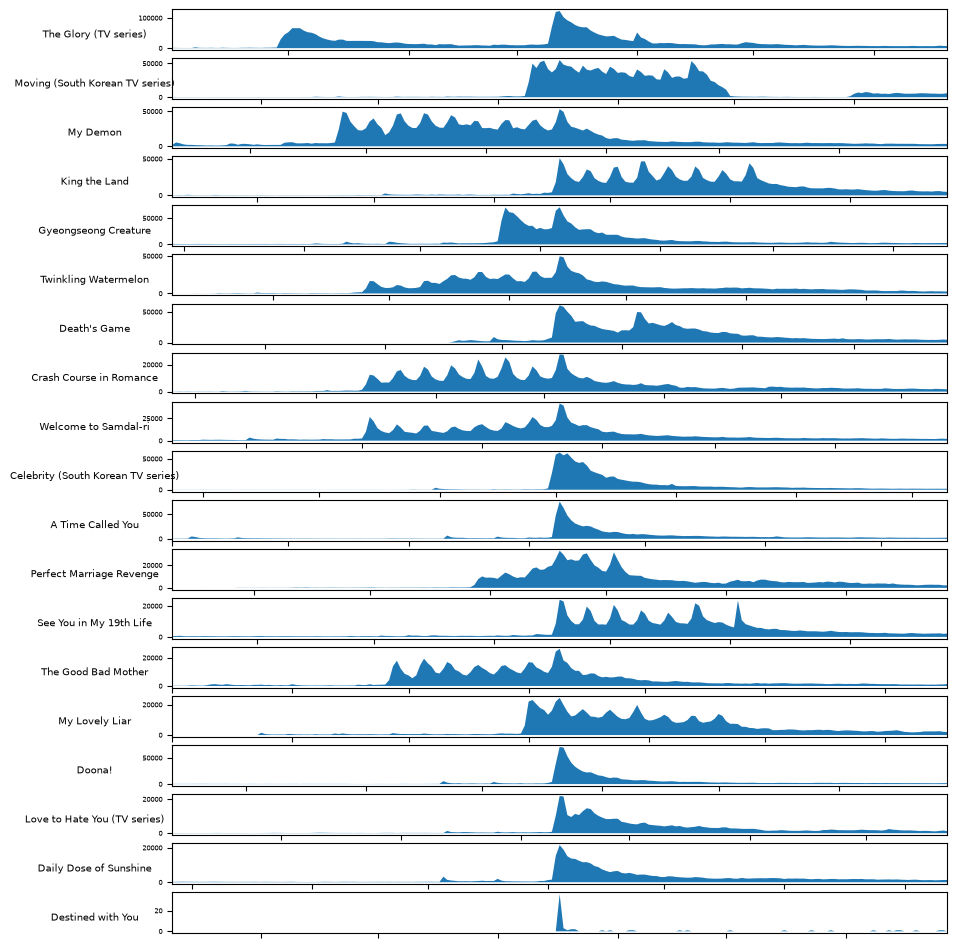

In [246]:
plt.style.use('default')

fig, ax = plt.subplots(nrows=19, ncols=1, figsize=(10, 12))

for i in range(19):
    ax[i].fill_between(df.index, df.iloc[:,i].astype(float).values)
    ax[i].set_ylabel(dramas[i], rotation=0, fontsize=7)
    ax[i].tick_params(axis='y', labelsize=5, )
    ax[i].yaxis.set_label_coords(-0.1, 0.25) 

    midpoint = df.iloc[:,i].idxmax()
    ax[i].set_xlim(midpoint - pd.Timedelta(days=100),midpoint + pd.Timedelta(days=100))
    ax[i].set_xticklabels([]) 


